In [91]:
import numpy as np
import matplotlib.pyplot as plt

# Operating conditions - FROM TABLE I
R_gon = 10      
V_dron = 6      
V_droff = -3    
V_dsSW = 500    
IL = 30         
f_sw = 50e3     

# Capacitances from Table I
C_iss_hv = 518e-12   
C_oss_hv = 126e-12   
C_rss_hv = 3.9e-12   
C_iss_lv = 600e-12   
C_oss_lv = 1000e-12  
C_rss_lv = 130e-12   
C_gd_hv = C_rss_hv
C_gs_hv = C_iss_hv - C_gd_hv
C_ds_hv = C_oss_hv - C_gd_hv
C_gd_lv = C_rss_lv
C_gs_lv = C_iss_lv - C_gd_lv
C_ds_lv = C_oss_lv - C_gd_lv

V_th = 1.7 #datasheet
Ls = 2e-9 #datasheet      
g_fs = 15
V_gs_miller = 3.0 


t_on1_t_on0 = -R_gon * (C_gd_hv + C_gs_hv) * np.log(1 - (V_th - V_droff) / (V_dron - V_droff))

print("ton1 - ton0 = ", t_on1_t_on0, "s")

if V_dron <= V_gs_miller:
    raise ValueError("Need V_dron > V_gs_miller for Stage 2 (Eq. 5).")

t_on2_t_on1 = (IL * (R_gon * (C_gd_hv + C_gs_hv) + Ls * g_fs)) / ((V_dron - V_gs_miller) * g_fs)

print("Stage 2: ton2 - ton1 =", t_on2_t_on1, "s")

t_on2_t_on0 = t_on1_t_on0 + t_on2_t_on1
print("ton2 - ton0 =", t_on2_t_on0, "s")

depth = 0.8 #paper says 0.8-0.9

di_dt = IL / t_on2_t_on1

# Stage t2→tP (Eq. 7-10)
Q_sto = (C_gs_lv + C_ds_lv) * (1 - depth) * V_dsSW  # Eq. 7
I_sto = np.sqrt(Q_sto * di_dt)  # Eq. 8
V_gs_miller_peak = I_sto / g_fs + V_gs_miller  # Eq. 9
t_onP_t_on1 = (IL * (R_gon * (C_gd_hv + C_gs_hv) + Ls * g_fs)) / ((V_dron - V_gs_miller_peak) * g_fs)  # Eq. 10

t_onP_t_on0 = t_on1_t_on0 + t_onP_t_on1
print("tonP - ton0", t_onP_t_on0, "s")

# Stage tP→tD (Eq. 11-13)
I_gdon = (V_dron - V_gs_miller) / R_gon  
C_rss_dynamic = 5.679e-10 * (V_dsSW ** -0.7523)  
t_D_t_P = (C_rss_dynamic * V_dsSW) / I_gdon  

t_D_t_on0 = t_onP_t_on0 + t_D_t_P 
print("tD - ton0", t_D_t_on0, "s")
print("tD - tP  ", t_D_t_P, "s")

# Stage tP→t3 (Eq. 14)
t_on3_t_onP = (C_gd_lv * (1 - depth) * V_dsSW * R_gon) / (V_dron - V_gs_miller)

# Stage t3→t4 (Eq. 15)
t_on4_t_on3 = -R_gon * (C_gd_lv + C_gs_lv) * np.log(1 - (depth * V_dron - V_gs_miller) / (V_dron - V_droff))

# Losses (Eq. 16)
E_on = V_dsSW * (IL + I_sto) * (t_onP_t_on1 / 2) + V_dsSW * I_sto * (t_D_t_P / 3) + V_dsSW * IL * (t_D_t_P / 2)
P_on = E_on * f_sw
t_onP_t_on2 = t_onP_t_on1 - t_on2_t_on1
t_total = t_on1_t_on0 + t_on2_t_on1 + t_onP_t_on2 + t_on3_t_onP + t_on4_t_on3


ton1 - ton0 =  3.82599749301812e-09 s
Stage 2: ton2 - ton1 = 2.3453333333333334e-08 s
ton2 - ton0 = 2.7279330826351455e-08 s
tonP - ton0 3.690249016489121e-08 s
tD - ton0 4.572689622166929e-08 s
tD - tP   8.824406056778081e-09 s


In [ ]:
print("\nTIMING PARAMETERS ")
print(f"Stage 1 (Delay):         t1 - t0  = {t_on1_t_on0*1e9:8.3f} ns")
print(f"Stage 2 (Current Rise):  t2 - t1  = {t_on2_t_on1*1e9:8.3f} ns")
print(f"Stage 3 (Overshoot):     tP - t2  = {t_onP_t_on2*1e9:8.3f} ns")
print(f"Stage 4 (Settling):      tD - tP  = {t_D_t_P*1e9:8.3f} ns")
print(f"Stage 5 (Voltage Fall):  t4 - tD  = {(t_on3_t_onP + t_on4_t_on3)*1e9:8.3f} ns")
print(f"TOTAL TURN-ON TIME:      t_total = {t_total*1e9:8.3f} ns")

print("\nCRITICAL VALUES ")
print(f"Current di/dt:                     {di_dt/1e9:8.3f} GA/s")
print(f"Stored Charge (Qsto):              {Q_sto*1e9:8.3f} nC")
print(f"Overshoot Current (Isto):          {I_sto:8.3f} A")
print(f"Peak Current (IL + Isto):          {IL + I_sto:8.3f} A")
print(f"Peak Gate Voltage:                 {V_gs_miller_peak:8.3f} V")
print(f"Gate Drive Current (Igdon):        {I_gdon:8.3f} A")
print(f"Dynamic Crss:                      {C_rss_dynamic*1e12:8.3f} pF")

print("\nSWITCHING LOSSES ")
print(f"Turn-On Energy (Eon):              {E_on*1e6:8.3f} μJ")
print(f"Turn-On Power (Pon):               {P_on:8.3f} W")
print(f"Switching Frequency:               {f_sw/1e3:8.1f} kHz")
print(f"Duty Cycle (switching):            {(t_total*f_sw)*100:8.4f} %")

print("PERFORMANCE METRICS ")
print(f"Overshoot vs Load Current:         {(I_sto/IL)*100:8.1f} %")
print(f"Peak vs Load Current:              {((IL+I_sto)/IL)*100:8.1f} %")
print(f"Energy per Switching Period:       {(E_on/(1/f_sw))*1e3:8.3f} mW")


{'t0': 0.0, 't1': np.float64(3.82599749301812e-09), 't2': np.float64(2.7279330826351455e-08), 'tP': np.float64(3.690249016489121e-08), 'tD': np.float64(4.572689622166929e-08), 't3': np.float64(8.023582349822453e-08), 't4': np.float64(8.157468480610979e-08)}
E_on (Eq16) = 0.0004417723472759066 J
E_num (trapz Vds*Id) = 0.0005061163176888395 J
ratio E_num/E_on = 1.1456496107320795


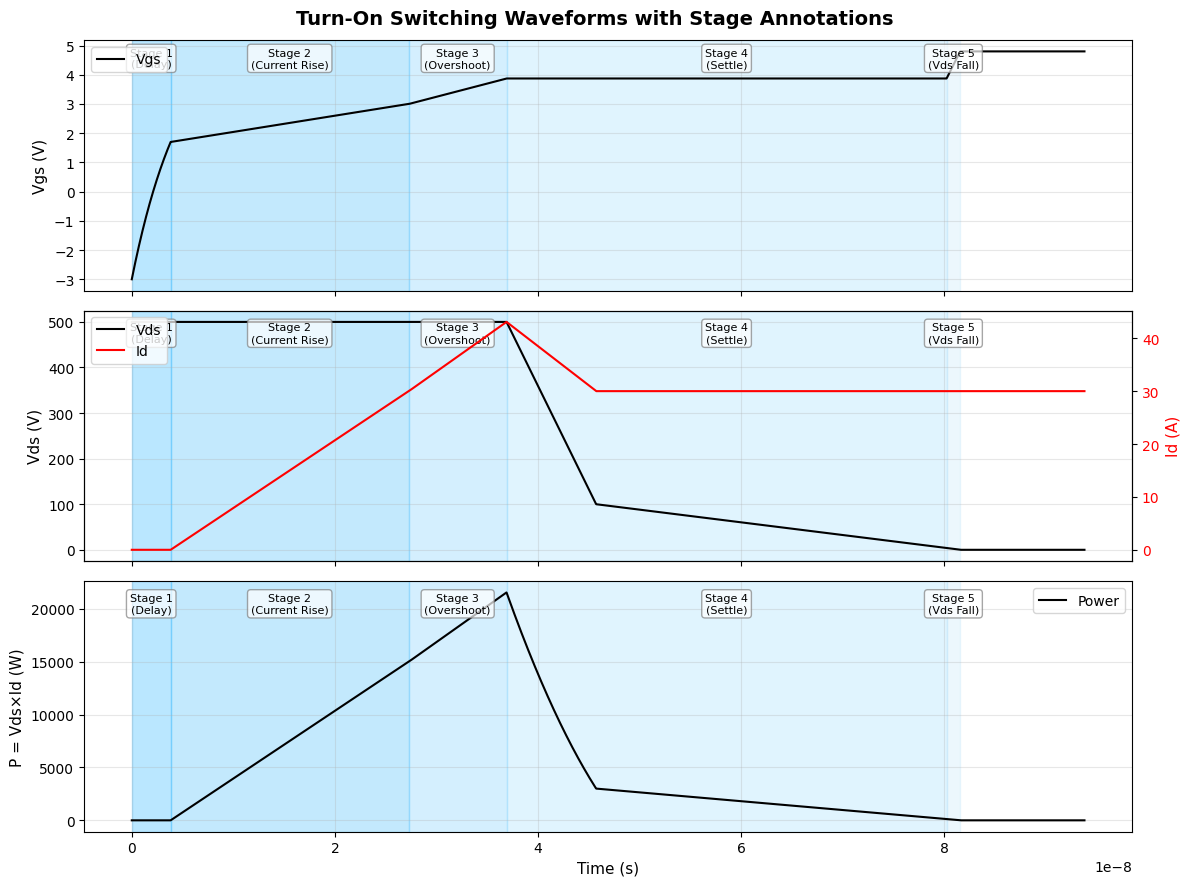

In [112]:
import numpy as np
import matplotlib.pyplot as plt

t0 = 0.0
t1 = t_on1_t_on0
t2 = t_on2_t_on0
tP = t_onP_t_on0
tD = t_D_t_on0

t3 = tP + t_on3_t_onP
t4 = t3 + t_on4_t_on3

times = {"t0": t0, "t1": t1, "t2": t2, "tP": tP, "tD": tD, "t3": t3, "t4": t4}
print(times)

if not (t0 <= t1 <= t2 <= tP <= t4):
    print("WARNING: Stage ordering unexpected. Check parameters.")
if tD < tP:
    print("WARNING: tD < tP; check Eq. 11–13 inputs.")

t_end = t4 * 1.15
N = 4000
t = np.linspace(0, t_end, N)

def linseg(t, ta, tb, ya, yb):
    return ya + (yb - ya) * (t - ta) / (tb - ta)

Vgs = np.zeros_like(t)

tau_in = R_gon * (C_gd_hv + C_gs_hv)  # = Rgon*Ciss_hv

for k, tk in enumerate(t):
    if tk <= t1:
        # Stage 1: RC rise from V_droff to V_th
        Vgs[k] = V_droff + (V_dron - V_droff) * (1 - np.exp(-(tk - t0)/tau_in))
    elif tk <= t2:
        # Stage 2: rise from Vth to Vgs_miller (simple linear ramp)
        Vgs[k] = linseg(tk, t1, t2, V_th, V_gs_miller)
    elif tk <= tP:
        # Stage t2 -> tP: rise from Vgs_miller to Vgs_miller_peak
        Vgs[k] = linseg(tk, t2, tP, V_gs_miller, V_gs_miller_peak)
    elif tk <= t3:
        # Stage tP -> t3: Miller-ish (hold near plateau)
        Vgs[k] = V_gs_miller_peak
    elif tk <= t4:
        # Stage t3 -> t4: rise from plateau to depth*Vdron (matches Eq. 15 endpoint idea)
        Vgs[k] = linseg(tk, t3, t4, V_gs_miller_peak, depth * V_dron)
    else:
        Vgs[k] = depth * V_dron

Id = np.zeros_like(t)

for k, tk in enumerate(t):
    if tk <= t1:
        Id[k] = 0.0
    elif tk <= t2:
        # Stage 2: current rises 0 -> IL
        Id[k] = linseg(tk, t1, t2, 0.0, IL)
    elif tk <= tP:
        # Stage t2 -> tP: overshoot up to IL+I_sto (triangular up)
        Id[k] = linseg(tk, t2, tP, IL, IL + I_sto)
    elif tk <= tD:
        # Stage tP -> tD: settle back to IL (triangular down)
        Id[k] = linseg(tk, tP, tD, IL + I_sto, IL)
    else:
        # after settling: ~constant IL
        Id[k] = IL

Vds = np.zeros_like(t)

Vds_mid = (1 - depth) * V_dsSW  # intermediate level using depth (per paper's depth meaning)

for k, tk in enumerate(t):
    if tk <= tP:
        Vds[k] = V_dsSW
    elif tk <= tD:
        # fast initial fall: VdsSW -> Vds_mid
        Vds[k] = linseg(tk, tP, tD, V_dsSW, Vds_mid)
    elif tk <= t4:
        # remaining fall to ~0 by t4
        Vds[k] = linseg(tk, tD, t4, Vds_mid, 0.0)
    else:
        Vds[k] = 0.0

P = Vds * Id
E_num = np.trapezoid(P, t) 

print("E_on (Eq16) =", E_on, "J")
print("E_num (trapz Vds*Id) =", E_num, "J")
print("ratio E_num/E_on =", E_num / E_on if E_on != 0 else np.nan)

stages = [
    (t0, t1, "Stage 1\n(Delay)", "#1db0ff"),    
    (t1, t2, "Stage 2\n(Current Rise)", "#3ab8fbff"), 
    (t2, tP, "Stage 3\n(Overshoot)", "#73cdfd"),   
    (tP, t3, "Stage 4\n(Settle)", "#99dbfe"),  
    (t3, t4, "Stage 5\n(Vds Fall)", "#c2e6f9"),  
]

def add_stage_shading(ax, stages):
    for t_start, t_end, label, color in stages:
        ax.axvspan(t_start, t_end, alpha=0.3, color=color, zorder=0)
        # Add label at the center of each region
        t_center = (t_start + t_end) / 2
        ymin, ymax = ax.get_ylim()
        ax.text(t_center, ymax * 0.95, label, 
                ha='center', va='top', fontsize=8, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor='gray', alpha=0.7))

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Turn-On Switching Waveforms with Stage Annotations', fontsize=14, fontweight='bold')

# Vgs
axes[0].plot(t, Vgs, 'k-', linewidth=1.5, label='Vgs')
axes[0].set_ylabel('Vgs (V)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left')
add_stage_shading(axes[0], stages)

# Vds and Id combined
ax1 = axes[1]
ax2 = ax1.twinx()

line1 = ax1.plot(t, Vds, 'k-', linewidth=1.5, label='Vds')
line2 = ax2.plot(t, Id, 'r-', linewidth=1.5, label='Id')

ax1.set_ylabel('Vds (V)', fontsize=11, color='k')
ax2.set_ylabel('Id (A)', fontsize=11, color='r')
ax1.tick_params(axis='y', labelcolor='k')
ax2.tick_params(axis='y', labelcolor='r')
ax1.grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

add_stage_shading(ax1, stages)

# Power
axes[2].plot(t, P, 'k-', linewidth=1.5, label='Power')
axes[2].set_ylabel('P = Vds×Id (W)', fontsize=11)
axes[2].set_xlabel('Time (s)', fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right')

add_stage_shading(axes[2], stages)

plt.tight_layout()
plt.savefig("trying.png")
plt.show()

In [101]:
print("t4-t3 ns:", (t4-t3)*1e9)
print("Vgs min/max:", Vgs.min(), Vgs.max())
print("count > 3.1V:", np.sum(Vgs > 3.1))


t4-t3 ns: 1.3388613078852614
Vgs min/max: -3.0 4.800000000000001
count > 3.1V: 940
